## PROJET CONTROLE DE PORTEFEUILLE
### Analyse des Donnees

Cet ensemble de données contient les prix historiques et le volume de 4 crypto-monnaies de November 9, 2017 à August 27, 2022.

- BTC - Bitcoin
- BNB – Pièce de monnaie Binance
- ETH - Ethereum
- USDT – Tether

#### Colonnes et leur signification :

1) Date

Représente la date et l'heure en format ISO.
- Exemple : 2017-11-13 00:00:00+00:00 signifie le 13 novembre 2017 à minuit en temps universel coordonné.

2) Close (BTC)

Prix de clôture du Bitcoin (BTC) pour la journée indiquée.
- Exemple : 6559.490234 signifie que BTC valait environ 6 559,49 USD à la clôture de la journée.

3) Volume (BTC)

Volume échangé en Bitcoin pendant la journée.
- Exemple : 6263249920 indique que la valeur totale des transactions BTC est d'environ 6,26 milliards de dollars.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("../data/crypto_data_updated_27_august.csv", index_col=0, parse_dates=True)
data.head()


,Adj Close (BNB),Volume (BNB),Adj Close (BTC),Volume (BTC),Adj Close (USDT),Volume (USDT),Adj Close (ETH),Volume (ETH)
Date,,,,,,,,
09/11/2017,1.99077,19192200,7143.580078,3226249984,1.00818,358188000,320.884003,893249984
10/11/2017,1.79684,11155000,6618.140137,5208249856,1.00601,756446016,299.252991,885985984
11/11/2017,1.67047,8178150,6357.600098,4908680192,1.00899,746227968,314.681000,842300992
12/11/2017,1.51969,15298700,5950.069824,8957349888,1.01247,1466060032,307.907990,1613479936
13/11/2017,1.68662,12238800,6559.490234,6263249920,1.00935,767884032,316.716003,1041889984


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2017-11-13 00:00:00+00:00 to 2022-11-13 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1827 non-null   float64
 1   Volume (BTC)   1827 non-null   int64  
 2   Close (ETH)    1827 non-null   float64
 3   Volume (ETH)   1827 non-null   int64  
 4   Close (USDT)   1827 non-null   float64
 5   Volume (USDT)  1827 non-null   int64  
 6   Close (BNB)    1827 non-null   float64
 7   Volume (BNB)   1827 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.5 KB


In [2]:
data[:12]

,Adj Close (BNB),Volume (BNB),Adj Close (BTC),Volume (BTC),Adj Close (USDT),Volume (USDT),Adj Close (ETH),Volume (ETH)
Date,,,,,,,,
09/11/2017,1.99077,19192200,7143.580078,3226249984,1.00818,358188000,320.884003,893249984
10/11/2017,1.79684,11155000,6618.140137,5208249856,1.00601,756446016,299.252991,885985984
11/11/2017,1.67047,8178150,6357.600098,4908680192,1.00899,746227968,314.681000,842300992
12/11/2017,1.51969,15298700,5950.069824,8957349888,1.01247,1466060032,307.907990,1613479936
13/11/2017,1.68662,12238800,6559.490234,6263249920,1.00935,767884032,316.716003,1041889984
14/11/2017,1.59258,7829600,6635.750000,3197110016,1.00683,429857984,337.631012,1069680000
15/11/2017,1.53045,7615500,7315.540039,4200880128,1.00318,449671008,333.356995,722665984
16/11/2017,1.57792,8928640,7871.689941,5123809792,1.00212,650278976,330.924011,797254016
17/11/2017,1.51036,8508840,7708.990234,4651670016,1.00139,639398016,332.394012,621732992


In [3]:
data.describe()


,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03
mean,20228.315369,2.630272e+10,1129.229883,1.308885e+10,1.001606,4.156009e+10,143.886168,9.717711e+08
std,17028.454586,1.995516e+10,1203.999710,1.086878e+10,0.005771,3.842981e+10,184.167061,1.452963e+09
min,3236.761719,2.923670e+09,84.308296,6.217330e+08,0.966644,4.298580e+08,1.510360,9.284000e+03
25%,7666.110107,1.082725e+10,208.977219,4.495085e+09,0.999988,6.042266e+09,14.114409,1.360422e+08
50%,10793.339844,2.399141e+10,474.911011,1.095112e+10,1.000508,3.639024e+10,23.811028,3.480300e+08
75%,33734.515625,3.563229e+10,1802.761414,1.836356e+10,1.002518,6.090617e+10,293.938461,1.410656e+09
max,67566.828125,3.509679e+11,4812.087402,8.448291e+10,1.077880,2.790675e+11,675.684082,1.798295e+10


In [1]:
import pandas as pd
from util import ema, sma, rsi, macd, bandes_bollinger,WIN
 
def laod_data(path: str):
  data = pd.read_csv(path)
  data = data[3000000:3005000]
  
  
  data['ema'] = ema(data=data['Close'],fenetre_size=WIN)
  data['sma'] = sma(data=data['Close'],fenetre_size=WIN)
  data['rsi'] = rsi(data=data['Close'],fenetre_size=WIN)

  data['macd'], data['signal'] = macd(data=data['Close'],small_window=WIN,big_window=WIN+10,signal_window=9)
  data['bande_inf'], _ , data['bande_sup'] = bandes_bollinger(data=data['Close'],window_size=WIN)
  
  data.bfill(inplace= True)
  data.ffill(inplace= True)


  data.to_csv("../data/data_model.csv",index= False)
  return data

data1= laod_data('C:/Users/User/Desktop/s8/projet_tech/projet-controle-portefeuille/data/data.csv')

In [5]:
data2.head()
data2.shape

(1753, 8)

In [15]:
import pandas as pd
def laod_data(path: str):
  
  data = pd.read_csv(path)
  # data = data[:1000]
  
  data['ema'] = ema(data=data['Close'],fenetre_size=WIN)
  data['sma'] = sma(data=data['Close'],fenetre_size=WIN)
  data['rsi'] = rsi(data=data['Close'],fenetre_size=WIN)

  data['macd'], data['signal'] = macd(data=data['Close'],small_window=WIN,big_window=WIN+10,signal_window=9)
  data['bande_inf'], _ , data['bande_sup'] = bandes_bollinger(data=data['Close'],window_size=WIN)
  
  data.bfill(inplace= True)
  data.ffill(inplace= True)
  data.to_csv("../data/data_model2.csv")
 
data2 = pd.read_csv('C:/Users/User/Desktop/s8/projet_tech/projet-controle-portefeuille/data/crypto_data_updated_27_august.csv', index_col=0, parse_dates=True)
 
extracted_data = data2[['Adj Close (BTC)', 'Volume (BTC)']]
 
extracted_data.rename(columns={'Adj Close (BTC)': 'Close', 'Volume (BTC)': 'Volume'}, inplace=True)
 
extracted_data.to_csv('../data/data_model.csv')
laod_data('C:/Users/User/Desktop/s8/projet_tech/projet-controle-portefeuille/data/data_model.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_932\1758399827.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extracted_data.rename(columns={'Adj Close (BTC)': 'Close', 'Volume (BTC)': 'Volume'}, inplace=True)


In [3]:
data['Close (BTC)'][1250]

C:\Users\User\AppData\Local\Temp\ipykernel_23876\1089429626.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['Close (BTC)'][1250]


np.float64(61572.7890625)

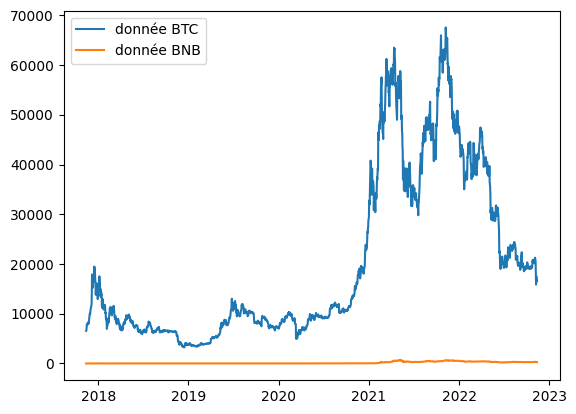

In [13]:
plt.plot(data['Close (BTC)'], label= 'donnée BTC')
plt.plot(data['Close (BNB)'],label='donnée BNB')
plt.legend()
plt.show()

In [4]:
import random
mini= random.sample([(12,13), (11,17), ( 20, 21)], 3)
x,y=zip(*mini)
print ( x)
print(y)
#print( mini)

(12, 20, 11)
(13, 21, 17)


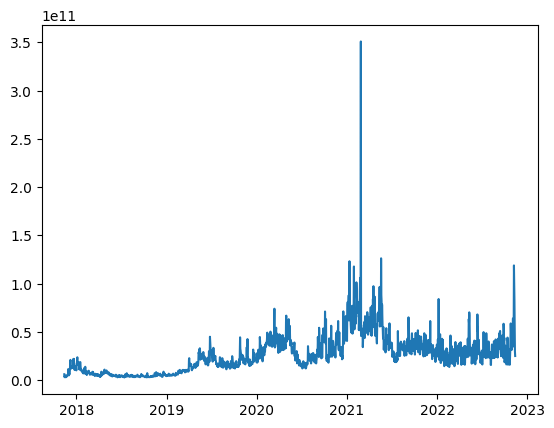

In [14]:
plt.plot(data["Volume (BTC)"])
plt.show()

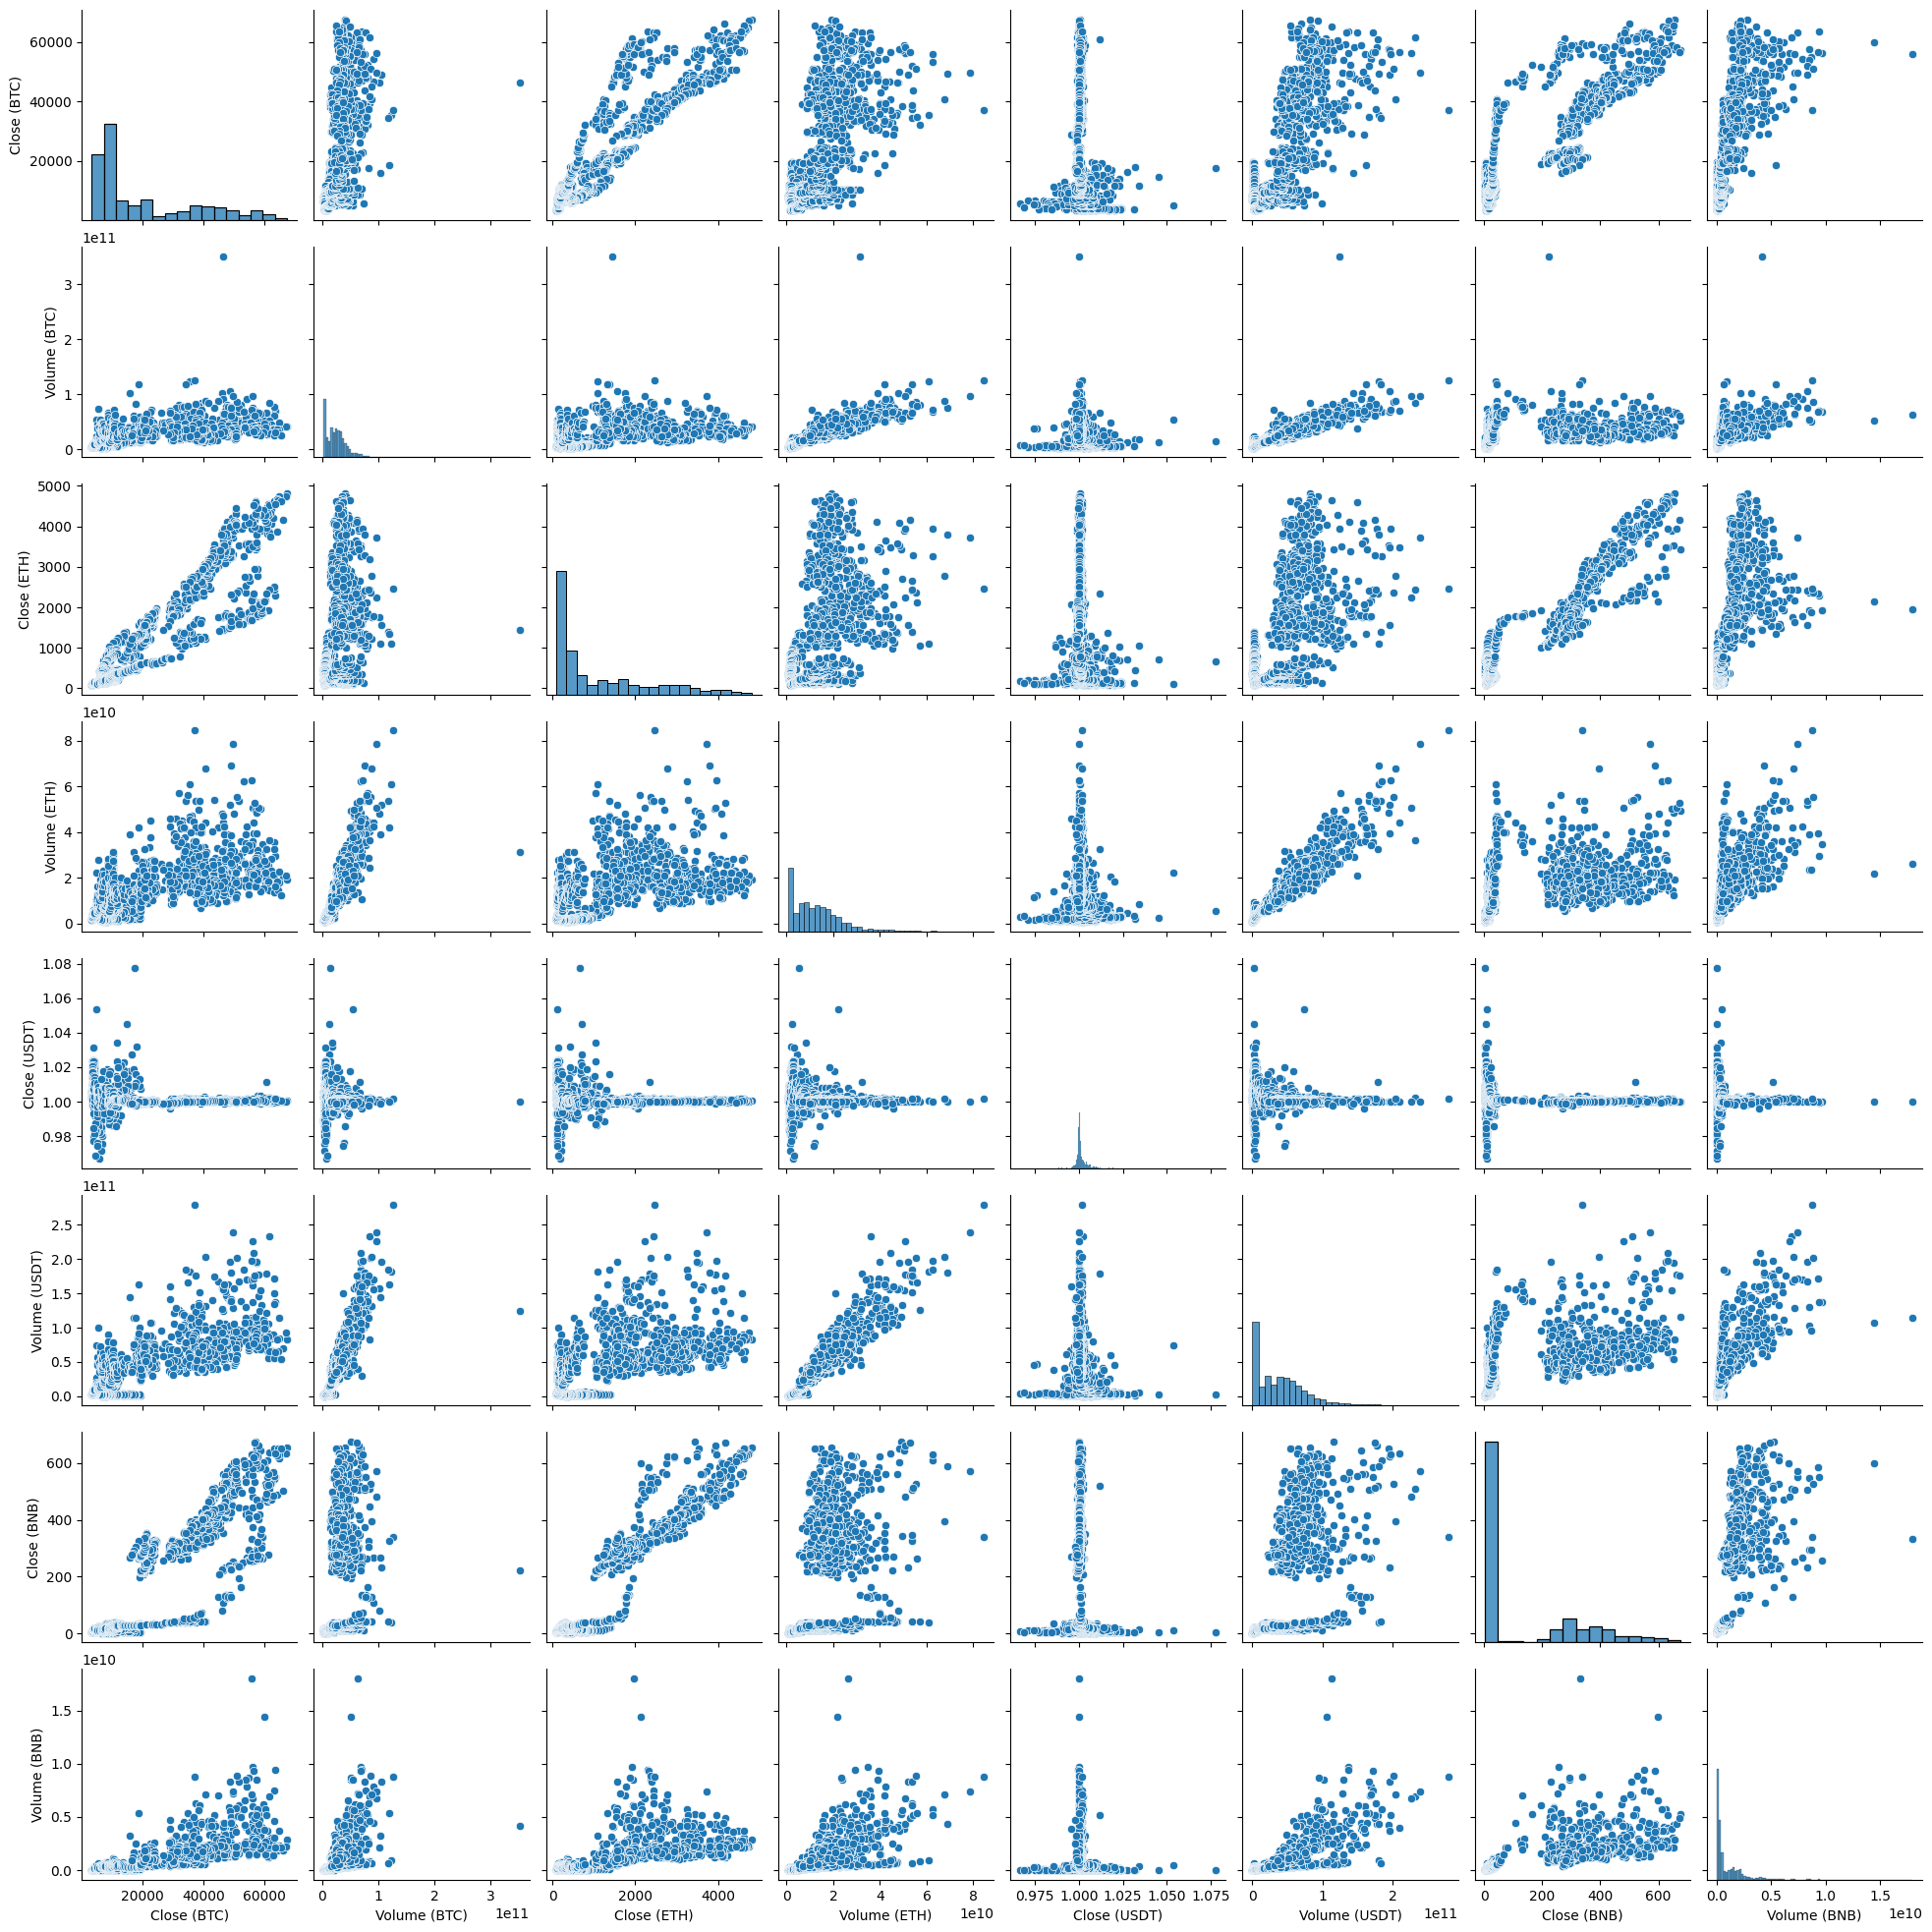

In [17]:
import seaborn as sns
sns.pairplot(data)

In [40]:
#SMA
df= pd.DataFrame({'prix':[10,13,20,24,25,9,2,1,0.8]})
WIN=3

def sma(data,fenetres_size):
    return(data.rolling(window= fenetres_size)).mean()

df['Data_sma']= sma(df,WIN)

# EMA
def ema(data: pd.DataFrame, fenetre_size):
    return(data.ewm(span=fenetre_size,adjust=False).mean())
df["ema"]= ema(df['prix'],WIN)

def rsi(data,fenetre_size):
    delta= data.diff(1)
    gain_mean= (data.where(delta>0)).rolling(window= fenetre_size).mean()
    perte_mean =(data.where(delta<0)).rolling(window= fenetre_size).mean()
    rs= gain_mean/perte_mean
    rsi= 100 - (100/(1+rs))
    return rsi


df['rsi']= rsi
    